# Extended EOF Analysis

Time-extended EOF (EEOF) analysis applies standard EOF decomposition to a lag-augmented space–time matrix, extracting patterns that evolve across multiple time periods. This notebook demonstrates the method on tropical OLR anomalies, building on the EOF workflow from [3D EOFs](./eofs-3d.ipynb).

---

## Overview

Standard EOF analysis (see [3D EOFs](./eofs-3d.ipynb)) identifies dominant spatial patterns and their temporal evolution from a space–time field. A limitation is that **propagating** signals, patterns that move across the domain over time, often appear as *pairs* of EOF modes with similar variance, with phase information split across two principal components.

**Time-extended EOF (EEOF)** analysis addresses this by applying EOF decomposition to a **lag-augmented** data matrix: each row stacks the field at several time offsets. Each eigenmode then carries a sequence of spatial patterns at different lags, revealing how a structure evolves in time.

In this notebook we demonstrate EEOF on **monthly tropical Outgoing Longwave Radiation (OLR)** anomalies, a classic variable for monitoring tropical convection and variability linked to ENSO and the MJO. The workflow is:

1. Mathematical background: how the extended matrix is built and how it connects to standard EOF
2. Load NOAA OLR and compute monthly means
3. Remove the seasonal cycle by harmonic regression
4. Build the lag-augmented (extended) matrix
5. Form the temporal covariance matrix and solve the eigenvalue problem
6. Recover lagged spatial EEOF patterns and principal component time series
7. Interpret the leading modes in the context of tropical interannual variability


## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| Linear algebra | Necessary | Eigenvalues, eigenvectors, covariance matrices |
| [3D EOFs](./eofs-3d.ipynb) | Necessary | Covariance matrices, eigen-decomposition, PCs vs EOF maps |
| [2D EOFs](./eofs-2d.ipynb) | Necessary | Basic EOF / PCA workflow in a simpler setting |
| [Harmonic analysis](./harmonic_anomalies.ipynb) | Helpful | Seasonal cycle removal harmonic anomalies |

- **Time to learn**: 45


---

## Imports

In [2]:
import s3fs
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import CenteredNorm
import xarray as xr
from scipy import linalg as la
import cartopy.crs as ccrs
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.2)

## Mathematical background

### Why extend in time?

Propagating features (for example, an equatorial convective anomaly moving eastward) are poorly represented by a single static EOF map. Pairs of consecutive EOF modes with similar explained variance often indicate a propagating signal, with phase information distributed between the two principal components, as we saw in [3D EOFs](./eofs-3d.ipynb).

EEOF analysis encodes **temporal evolution directly in each eigenmode** by concatenating lagged fields side by side. Each mode then provides a *stack* of spatial patterns showing how the structure changes from one lag to the next.

### Building the extended matrix

Let $\mathbf{D} \in \mathbb{R}^{n_t \times m}$ be the anomaly field with **rows** as time and **columns** as flattened spatial points. (This is the transpose of the $\mathbf{X}$ layout used in [3D EOFs](./eofs-3d.ipynb); the mathematics is unchanged.)

Choose a maximum lag index $L$ and a lag step $\Delta$ (in time-index units). Define lag offsets $\tau_0 = 0,\, \tau_1 = \Delta,\, \ldots,\, \tau_L = L\Delta$. For each valid starting time $t$, form a row that concatenates spatial snapshots at those lags:

$$
\mathbf{r}_t = \bigl[\mathbf{d}_{t},\; \mathbf{d}_{t+\tau_1},\; \ldots,\; \mathbf{d}_{t+\tau_L}\bigr]
$$

where $\mathbf{d}_t \in \mathbb{R}^{m}$ is the spatial field at time $t$. Stacking these rows gives the **lag-augmented** (extended) matrix $\mathbf{L} \in \mathbb{R}^{n' \times m(L+1)}$, where $n' = n_t - L\Delta$ is reduced because the trailing time steps do not have enough history for all lags.

In the code below we set $L = 3$ and $\Delta = 6$ months, so each row contains the OLR anomaly field at lags $0$, $6$, $12$, and $18$ months, four spatial blocks concatenated horizontally:


$$
\mathbf{L} =
\begin{bmatrix}
\mathbf{D}_0 & \mathbf{D}_6 & \mathbf{D}_{12} & \mathbf{D}_{18}
\end{bmatrix}
$$

Each block $\mathbf{D}_{\tau}$ is an $(n' \times m)$ submatrix of $\mathbf{D}$ shifted by lag $\tau$.

### Overall workflow

The full EEOF pipeline mirrors standard EOF analysis, with one extra step:

1. **Preprocess**: remove the seasonal cycle so lag correlations reflect interannual and intraseasonal variability, not annual harmonics.
2. **Augment**: build $\mathbf{L}$ by horizontal concatenation of lagged fields.
3. **Diagonalize**: eigendecompose $\mathbf{L}\mathbf{L}^{\mathsf T}$. When $n' \ll m(L+1)$ this is cheaper than forming $\mathbf{L}^{\mathsf T}\mathbf{L}$, the same efficiency argument used in [3D EOFs](./eofs-3d.ipynb).
4. **Project**: recover lagged spatial patterns from the eigenvectors.
5. **Interpret**: inspect PC time series and the sequence of lagged spatial maps; propagating or oscillatory behavior often appears as mode pairs with similar variance and lagged PC cross-correlation.

---

## Access data

We use monthly NOAA interpolated OLR from the Project Pythia object store. OLR is a proxy for tropical convection: negative anomalies indicate enhanced convection and positive anomalies indicate suppressed convection. These patterns are central to diagnosing ENSO and MJO events.


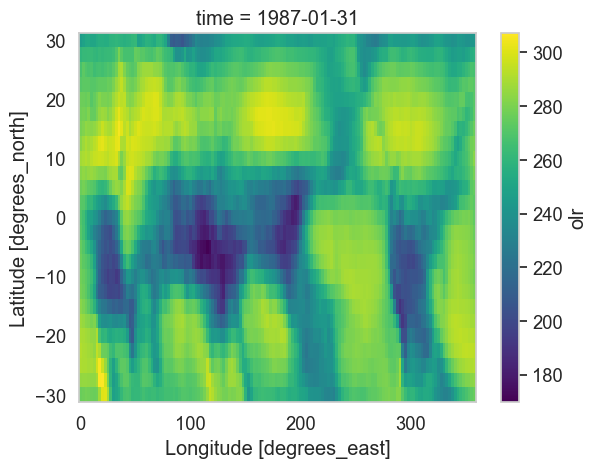

In [3]:
URL = 'https://js2.jetstream-cloud.org:8001/' #Locate and read a file
fs = s3fs.S3FileSystem(anon=True, client_kwargs=dict(endpoint_url=URL))

olr_noaa_store = s3fs.S3Map(
    root=f'pythia/olr_noaa.zarr',
    s3=fs,
    check=False
)

olr = xr.open_zarr(olr_noaa_store)
olr = olr.rename_vars({'__xarray_dataarray_variable__': 'olr'}).sel(
    time=slice('1987', None))
olr = olr.resample(time='ME').mean() # from daily to monthly
olr.olr.isel(time=0).plot()

## Deseasonalize

Before building lagged correlations, we remove the seasonal cycle with [**harmonic regression**](./harmonic_anomalies.ipynb), fitting a constant plus sin/cos pairs at annual harmonics and subtracting the fitted seasonal component.


In [5]:
n_time, n_lat, n_lon = olr.olr.shape # Number of time steps, latitude, longitude
data_2d = olr.olr.values.reshape(n_time, -1) # Reshape to 2D array

n_harmonics=4 # number of harmonics to fit
year_period=12 # number of months in a year 

# Build design matrix: 1 constant + n_harmonics sin/cos pairs
t = np.arange(n_time)
X = np.ones((n_time, 2 * n_harmonics + 1))
for i in range(1, n_harmonics + 1):
    X[:, 2*i - 1] = np.sin(i * 2 * np.pi * t / year_period)
    X[:, 2*i] = np.cos(i * 2 * np.pi * t / year_period)

# Solve via least squares and subtract seasonal component
coeffs = np.linalg.lstsq(X, data_2d, rcond=None)[0]
olr_anom = data_2d - X @ coeffs

Notice that the output anomalies matrix is a 2D array:

(456, 3600)


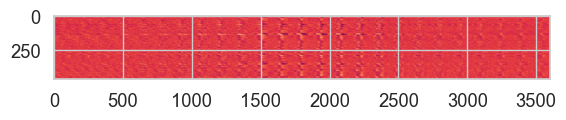

In [6]:
print(olr_anom.shape)
plt.imshow(olr_anom)

## Construct lagged matrix

The code below builds the extended matrix $\mathbf{L}$ as described in the mathematical background. Parameter `max_lag` ($L$) sets how many lag blocks to include; `lag_step` ($\Delta$) sets the spacing between them in months.

After construction, `lagged_matrix` has shape $(n',\, m(L+1))$. Grid points with missing values (for example, over land) are dropped before the covariance step.


In [10]:
max_lag = 3 # Maximum number of lags
lag_step = 6 # Lag step

lag_list = np.arange(0, lag_step*max_lag + 1, lag_step)
lag_list

array([ 0,  6, 12, 18])

In [14]:
data_matrix = olr_anom.copy()
n_time, n_space = data_matrix.shape

# Prepare the lagged matrix
lagged_matrix = np.zeros((n_time - lag_step*max_lag, n_space * (max_lag + 1))) * np.nan
for i in range(max_lag + 1):
    if (max_lag - i) != 0:
        lagged_matrix[:, i*n_space: i*n_space + n_space] = \
            data_matrix[lag_step*i:lag_step*i - lag_step*max_lag, :]
    else:
        lagged_matrix[:, i*n_space: i*n_space + n_space] = \
            data_matrix[lag_step*i:, :]

In [16]:
print('Original data matrix shape:', data_matrix.shape)
print('Lagged data matrix shape:', lagged_matrix.shape)

Original data matrix shape: (456, 3600)
Lagged data matrix shape: (438, 14400)


Notice that the lagged matrix there is an overall much smaller dimension than the other!

## Extended EOF analysis

We now follow the temporal EOF workflow from [3D EOFs](./eofs-3d.ipynb): compute $\mathbf{C} = \mathbf{L}\mathbf{L}^{\mathsf T}$, solve the eigenvalue problem, and project to recover spatial patterns at each lag. Results are wrapped as `xarray` DataArrays for plotting and downstream analysis.


In [18]:
data_3d = olr.olr

# Check for NaN values in the first row of the lagged matrix
nan_indices = np.where(np.isnan(lagged_matrix[0]))
lagged_matrix_no_nan = np.delete(lagged_matrix, nan_indices, 1)

cov_matrix = np.dot(lagged_matrix_no_nan, lagged_matrix_no_nan.T)
cov_matrix_2 = np.dot(lagged_matrix_no_nan.T, lagged_matrix_no_nan) # Bigger dimensionality

print('Covariance matrix shape:', cov_matrix.shape)
print('Covariance matrix shape:', cov_matrix_2.shape) 

Covariance matrix shape: (438, 438)
Covariance matrix shape: (14400, 14400)


Notice the dimesion of the smaller covariance matrix: `(438, 438)`. We are then going to use this one!

In [19]:
# Solve the eigenvalue problem
eigenvalues, eigenvectors = la.eig(cov_matrix)

total_variance = np.sum(eigenvalues)
variance_explained = (eigenvalues / total_variance) * 100

# Project eigenvectors onto the data to obtain the EOF spatial patterns
eof_modes = np.dot(eigenvectors.T, lagged_matrix_no_nan)

eof_with_nan = np.copy(lagged_matrix) * np.nan
all_space_indices = np.arange(lagged_matrix.shape[1])
valid_indices = np.setdiff1d(all_space_indices, nan_indices)
eof_with_nan[:, valid_indices] = eof_modes
eof_modes = eof_with_nan

n_modes, n_space_total = eof_modes.shape
eeofs = [np.copy(data_3d) * np.nan] * (max_lag + 1)

# Split the EOF matrix into its lag blocks
n_space_per_lag = int(n_space_total / (max_lag + 1))
eof_split = np.zeros((max_lag + 1, n_modes, n_space_per_lag)) * np.nan

for i in range(max_lag + 1):
    eof_split[i, :, :] = eof_modes[:, i*n_space_per_lag: (i + 1)*n_space_per_lag]

for i in range(max_lag + 1):
    eeofs[i] = eof_split[i, :, :].reshape(
        data_3d.shape[0] - 6*max_lag, data_3d.shape[1], data_3d.shape[2])

eeofs = np.array(eeofs)

## Saving the output to `Xarray` objects

In [ ]:
# Create the coordinates for the `xarray` objects
n_lag, n_modes, _, _ = eeofs.shape


eeof_coords = {
    'lag': lag_list,
    'mode': np.arange(n_modes),
    'lat': olr.lat.values,
    'lon': olr.lon.values,
}

eeof_da = xr.DataArray( 
    eeofs.astype('float32'),
    coords=eeof_coords,
    name='eof',
    attrs={'standard_name': 'EEOF'},
)

pc_coords = {
    'mode': np.arange(n_time - 6*max_lag),
    'time': olr.time.values[0:-6*max_lag],
}
pcs_da = xr.DataArray(
    eigenvectors.T.astype('float32'),
    coords=pc_coords,
    name='pc',
    attrs={'standard_name': 'PC',
           'long_name': 'Principal Components'},
)

variance_explained_coords = {
    'mode': np.arange(len(variance_explained)),
}
variance_explained_da = xr.DataArray(
    variance_explained.astype('float32'),
    coords=variance_explained_coords,
    name='var_exp',
    attrs={'standard_name': 'Variance Explained [%]'},
)

/var/folders/l0/gpl1qrb170s_gsc11vtdnlqcc1ytc6/T/ipykernel_42258/4065958492.py:31: ComplexWarning: Casting complex values to real discards the imaginary part
  variance_explained.astype('float32'),


### Creating a `dataset` with the output
The information is stored in the `xarray` objects. We can now create a dataset with the output:

In [22]:
ds_out = xr.Dataset({
    'eof': eeof_da,
    'pc': pcs_da,
    'var_exp': variance_explained_da,
})
ds_out.attrs['n_modes'] = int(n_modes)

# Uncomment to save to disk:
# ds_out.to_netcdf('chirps_eeof.nc')

ds_out

<xarray.Dataset> Size: 26MB
Dimensions:  (lag: 4, mode: 438, lat: 25, lon: 144, time: 438)
Coordinates:
  * lag      (lag) int64 32B 0 6 12 18
  * mode     (mode) int64 4kB 0 1 2 3 4 5 6 7 ... 431 432 433 434 435 436 437
  * lat      (lat) float32 100B 30.0 27.5 25.0 22.5 ... -22.5 -25.0 -27.5 -30.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 4kB 1987-01-31 1987-02-28 ... 2023-06-30
Data variables:
    eof      (lag, mode, lat, lon) float32 25MB -8.941 -12.58 ... -4.105 -4.422
    pc       (mode, time) float32 767kB 0.06778 0.05565 ... -0.01315 0.005836
    var_exp  (mode) float32 2kB 6.591 6.049 3.796 ... 0.04694 0.0465 0.04599
Attributes:
    n_modes:  438

## Plot results

### Variance Explained by each Mode.


The leading mode is by far the most important. Its principal component captures the dominant interannual signal in tropical OLR anomalies.

(0.0, 9.0)

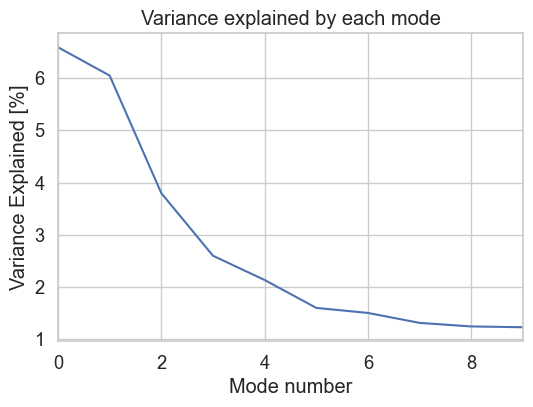

In [23]:
fig, ax = plt.subplots(figsize=(6, 4))
ds_out['var_exp'][:10].plot(ax=ax)
ax.set_title('Variance explained by each mode')
ax.set_xlabel('Mode number')
ax.set_xlim(0, 9)


### Principal Components (time series)

The first couple of principal component show a low-frequency variability related with ENSO

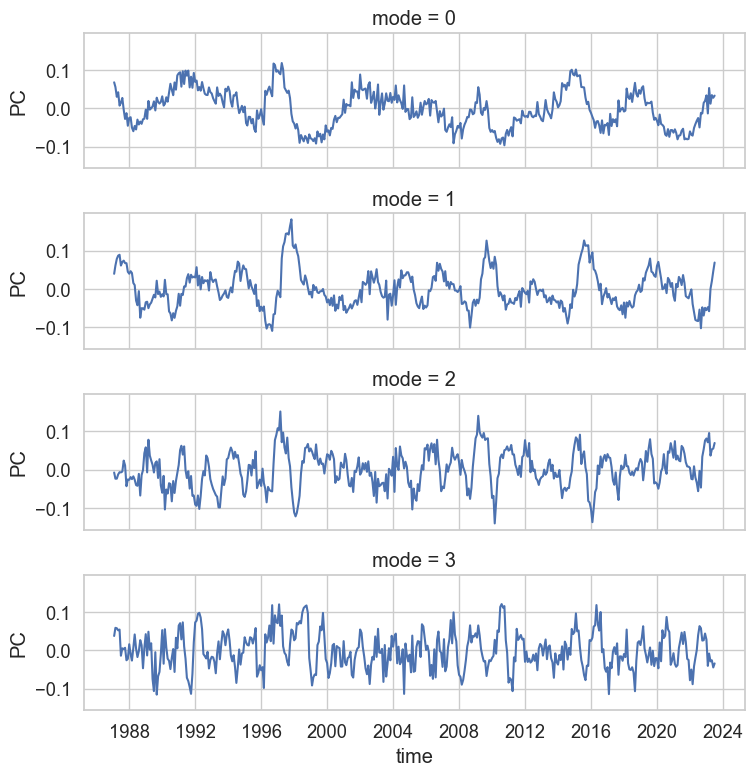

In [53]:
pc_plots = ds_out['pc'].isel(mode=slice(0, 4)).plot(row='mode',
                                              figsize=(8, 8))
[ax.grid(True) for ax in pc_plots.axs.flatten()];
[ax.set_ylabel('PC') for ax in pc_plots.axs.flatten()];

As in [3D EOFs](./eofs-3d.ipynb), lagged cross-correlation between pairs of PCs can reveal propagating behavior: modes that are uncorrelated at zero lag but correlated at a finite lag often indicate phase progression across a mode pair.

Text(0, 0.5, 'Correlation coefficient')

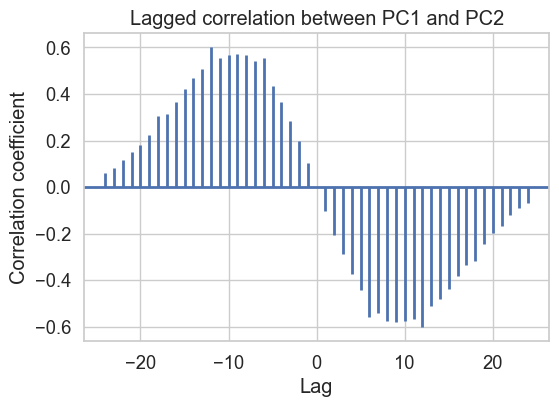

In [63]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.xcorr(ds_out['pc'].isel(mode=0), ds_out['pc'].isel(mode=1), maxlags=24,
          lw=2);
ax.set_title('Lagged correlation between PC1 and PC2')
ax.set_xlabel('Lag')
ax.set_ylabel('Correlation coefficient')

### Spatial Patterns

The first couple of modes show the typical ENSO pattern and a complementary transition between the two ENSO phases.

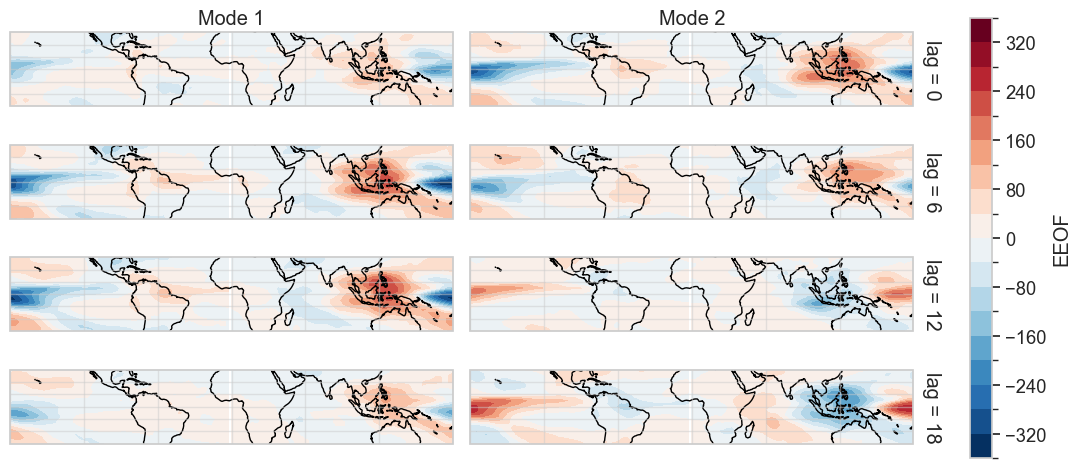

In [26]:
plots = ds_out['eof'].isel(mode=slice(0, 2)).plot.contourf(
    levels=21, col='mode', row='lag', subplot_kws={'projection': ccrs.PlateCarree()},
    figsize=(12, 5))

[ax.coastlines() for ax in plots.axs.flatten()]
[ax.gridlines(alpha=0.5) for ax in plots.axs.flatten()]

for ax, mode in zip(plots.axs[0], ['Mode 1', 'Mode 2']):
    ax.set_title(mode)


Mode 1 appears to be related to the onset of the ENSO event to its peak, and shows a transition from one stage to the other.

A closer look at Mode 2 at different lags reveals how the spatial pattern evolves. Watch how the sign and position of the anomaly change from lag 0 to lag 18 months—this temporal sequence is what standard single-snapshot EOF analysis cannot represent in one mode.

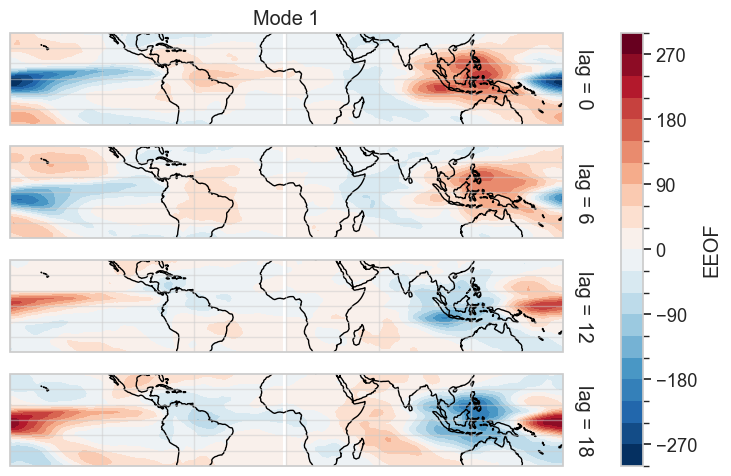

In [32]:
plots = ds_out['eof'].isel(mode=slice(1, 2)).plot.contourf(
    levels=21, col='mode', row='lag', subplot_kws={'projection': ccrs.PlateCarree()},
    figsize=(12, 5))

[ax.coastlines() for ax in plots.axs.flatten()]
[ax.gridlines(alpha=0.5) for ax in plots.axs.flatten()]

for ax, mode in zip(plots.axs[0], ['Mode 1', 'Mode 2']):
    ax.set_title(mode)

The OLR anomalies change sign over ~1 year, and it seems to be related to ENSO, since there are peaks in the first two PCs just before 1998 and 2016, years with strong positive ENSO.

In the following cell we show how to plot a single mode at a specific lag:

Text(0.5, 1.0, 'Mode 2, lag 6 months')

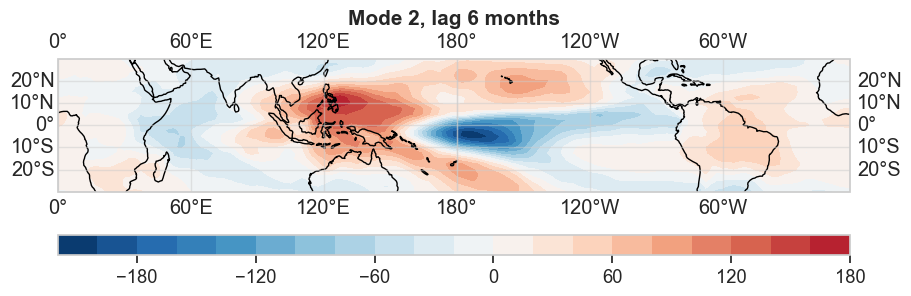

In [33]:
mode = 1 # Second mode
lag = 6 # months lag

fig = plt.figure(figsize=(9, 4), layout='constrained')
ax = plt.subplot(111, projection=ccrs.PlateCarree(central_longitude=180))
plot = ax.contourf(eeof_da.lon, eeof_da.lat, eeof_da.sel(mode=mode, lag=lag),
                   levels=21, transform=ccrs.PlateCarree(), cmap='RdBu_r',
                   norm=CenteredNorm())
ax.coastlines()
ax.gridlines(draw_labels=True, alpha=0.5)
plt.colorbar(plot, orientation='horizontal', aspect=40)
plt.title(f'Mode {mode +1}, lag {lag} months' , fontsize=15, fontweight='bold')

---

## Summary

We applied time-extended EOF (EEOF) analysis to monthly tropical OLR anomalies. The key steps were:

1. Remove the seasonal cycle with harmonic regression.
2. Build the lag-augmented matrix $\mathbf{L}$ by concatenating spatial fields at lags $0, 6, 12,$ and $18$ months.
3. Form the temporal covariance matrix $\mathbf{C} = \mathbf{L}\mathbf{L}^{\mathsf T}$ and solve $\mathbf{C}\,\mathbf{v}_k = \lambda_k\,\mathbf{v}_k$.
4. Project onto the eigenvectors to recover EEOF spatial patterns at each lag and rank modes by explained variance $p_k$.
5. Interpret PC time series and lagged spatial maps together—propagating signals such as ENSO-related OLR anomalies appear as modes whose spatial structure evolves across lags.

EEOF extends the EOF framework from [3D EOFs](./eofs-3d.ipynb) by embedding temporal evolution directly in each eigenmode, rather than relying on pairs of standard EOF modes to represent propagation.

### What's next?

TBD
